# Single-qubit deterministic benchmarking demo

This notebook compares the Gaussian and strictly resonant composite $X_\pi$ pulses. The amplitude error is injected into the sampled Hamiltonian before calculating the actual noisy gate and the sequence $[U_\epsilon U_\epsilon]^n$.

$$T_gH_\epsilon(s)=\frac12\left[(1+\epsilon)T_g\Omega_x(s)X+(1+\epsilon)T_g\Omega_y(s)Y+T_g\Delta(s)Z\right].$$

The numerical implementation is in [`db_helpers.py`](db_helpers.py).

In [20]:
from pathlib import Path
import sys

search_roots = (Path.cwd(), *Path.cwd().parents)
DEMO_DIR = next(
    path
    for root in search_roots
    for path in (root, root / "proposals/1qb-DB/1qb-DB-demo")
    if (path / "db_helpers.py").is_file()
)
sys.path.insert(0, str(DEMO_DIR))
import db_helpers as db

ERRORS = (-0.03, 0.03)
N_CYCLES = 60
WAVEFORM_DIR, metadata, pulses = db.load_experiment_inputs()
print(WAVEFORM_DIR)

/Users/wenzheng/Desktop/QElements/Gate_construction/pulse-shape-Novera/proposals/1qb-DB/X_gate_pulse_generation/waveforms


## 1. Imported control waveforms

Both controls come directly from the saved CSV files. No pulse formula is reconstructed in this notebook.

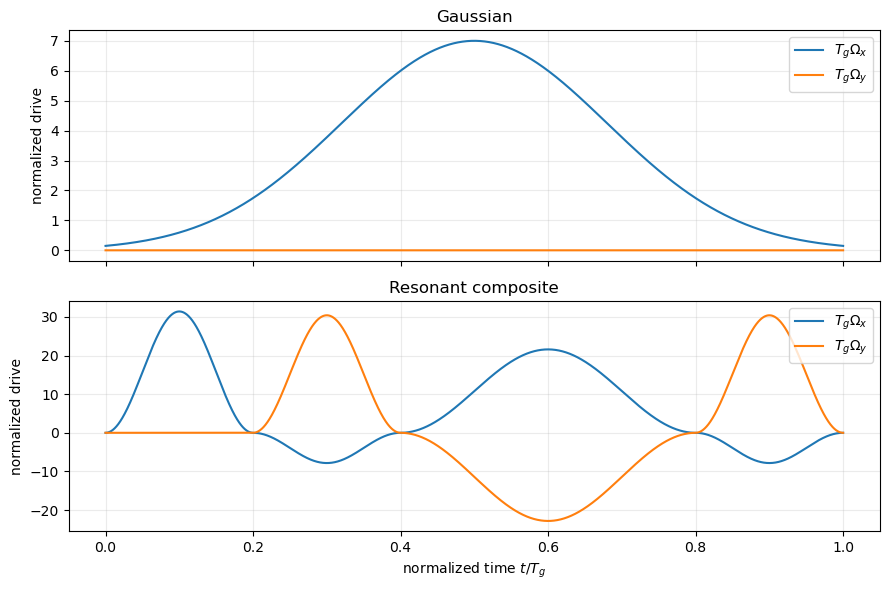

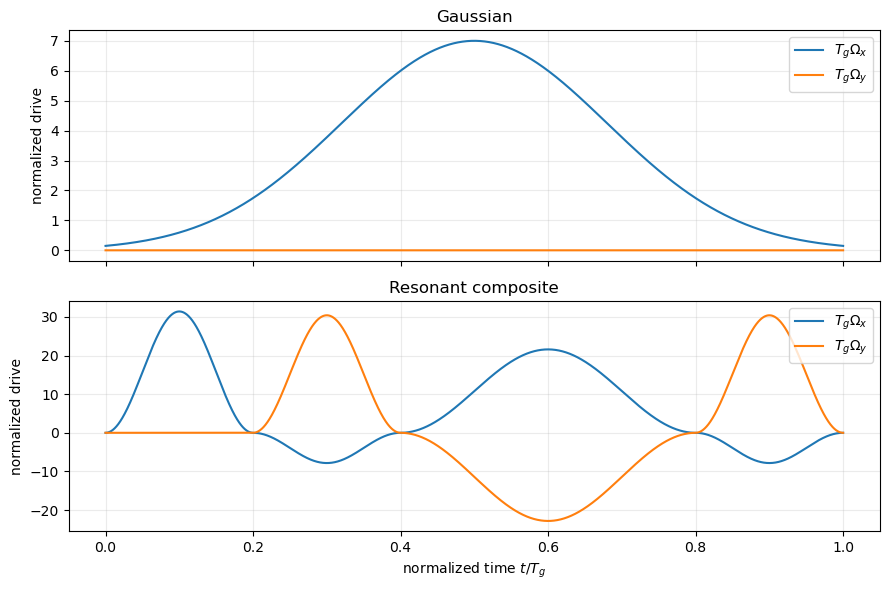

In [21]:
for name, pulse in pulses.items():
    assert abs(pulse["Tg_delta"]).max() < 1e-12, f"{name} is not resonant"
db.plot_controls(pulses)

## 2. Error injection and time-ordered gate

For each sampled interval, the helper constructs $H_{\epsilon,j}$, calculates
$U_j=\exp(-iH_{\epsilon,j}\Delta s_j)$, and forms
$U_\epsilon(T_g)=U_N\cdots U_2U_1$. The DB result therefore comes from the full waveform Hamiltonian.

In [22]:
gates = db.calculate_gates(pulses, ERRORS)
for name in pulses:
    fidelity = db.average_gate_fidelity(gates[name][0.0])
    print(f"{name:20s} zero-error fidelity = {fidelity:.12f}")

Gaussian             zero-error fidelity = 1.000000000000
Resonant composite   zero-error fidelity = 1.000000000000


## 3. Actual noisy gates

These are the numerical gate matrices obtained after injecting $\epsilon=\pm3\%$ into the Hamiltonian.

In [23]:
db.print_gate_report(gates, ERRORS)


Gaussian
epsilon=-3%, ||U_dagger U-I||=5.97e-15
[[0.0471065+0.j        0.       -0.9988899j]
 [0.       -0.9988899j 0.0471065+0.j       ]]
epsilon=+3%, ||U_dagger U-I||=1.26e-15
[[-0.0471064+0.j         0.       -0.9988899j]
 [ 0.       -0.9988899j -0.0471064+0.j       ]]

Resonant composite
epsilon=-3%, ||U_dagger U-I||=7.09e-15
[[ 0.0000164+0.0000001j -0.       -1.j       ]
 [ 0.       -1.j         0.0000164-0.0000001j]]
epsilon=+3%, ||U_dagger U-I||=1.46e-14
[[-0.0000164-0.0000001j -0.       -1.j       ]
 [ 0.       -1.j        -0.0000164+0.0000001j]]


## 4. Deterministic-benchmarking comparison

Both pulses are shown on one graph. Color identifies the pulse. The connected open circles identify $-3\%$; the thicker solid lines identify $+3\%$. The markers remain visible when the two error signs overlap.

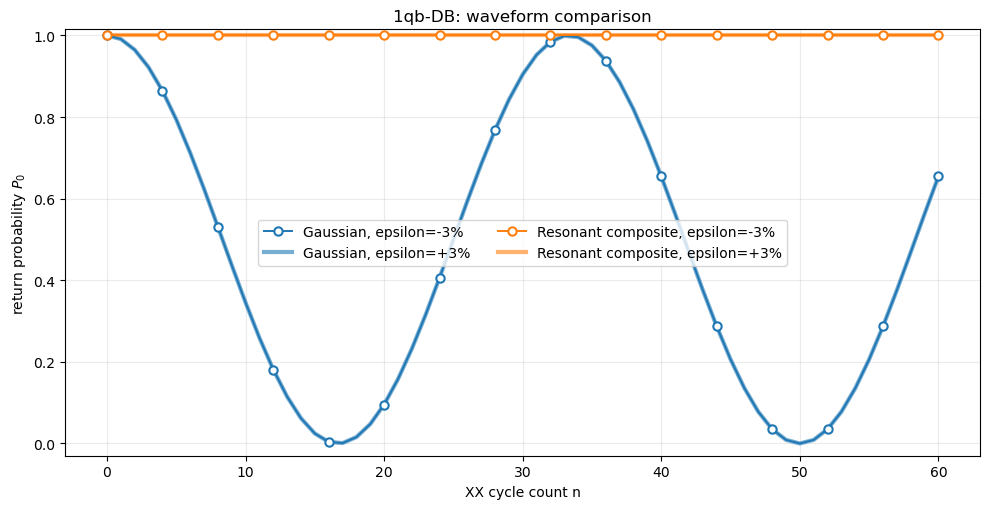

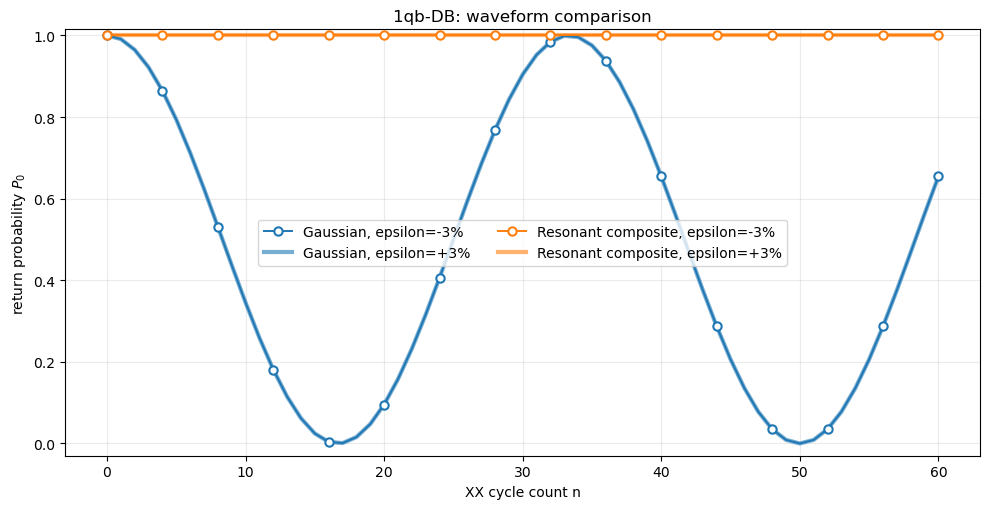

In [24]:
traces, results = db.calculate_db_results(
    pulses, gates, ERRORS, N_CYCLES
)
db.plot_db_comparison(traces, N_CYCLES)

In [25]:
db.print_results_table(results, ERRORS)

pulse                  error         F_gate      P0(final)       Delta P0
---------------------------------------------------------------------------
Gaussian                 -3% 0.998520653017    0.654511864   1.000000e+00
Gaussian                 +3% 0.998520656833    0.654504923   1.000000e+00
Resonant composite       -3% 0.999999999822    0.999996147   3.852586e-06
Resonant composite       +3% 0.999999999822    0.999996147   3.852584e-06


## 5. Reproducibility checks

Compare this independent Hamiltonian propagation with the saved waveform metadata.

In [26]:
db.validate_results(metadata, gates, results, ERRORS, N_CYCLES)
print("All Hamiltonian-evolution, metadata, and DB checks passed.")

All Hamiltonian-evolution, metadata, and DB checks passed.


## Conclusion

At $\pm3\%$ amplitude error, the Gaussian covers essentially the full $P_0$ range within 60 cycles. The resonant composite pulse suppresses the simulated variation to approximately $3.9\times10^{-6}$ while retaining near-unit $X_\pi$ fidelity.